# Assignment 3

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
import nbformat, base64, re
from pathlib import Path

nb_file = "Assign3.ipynb"

# Load notebook
nb = nbformat.read(nb_file, as_version=4)

for cell in nb.cells:
    if cell.cell_type == "markdown":
        matches = re.findall(r'!\[\]\((.*?)\)', cell.source)
        for img_path in matches:
            path = Path(img_path)
            if path.exists():
                ext = path.suffix[1:]  # e.g., 'jpg' or 'png'
                data = base64.b64encode(path.read_bytes()).decode()
                img_tag = f'<img src="data:image/{ext};base64,{data}">'
                cell.source = cell.source.replace(f"![]({img_path})", img_tag)

# Save notebook with embedded images
nbformat.write(nb, "Assign3.ipynb")


1. Recall the coffee-cooling problem discussed in class. In this assignment, let's assume that the cooling rate $r$ is not a constant but decays with time as $r(t) = \exp(-\alpha t^2)$. Take the initial temperature of the coffee-cup to be $85^{\circ}$C and the surrounding temperature to be $25^{\circ}$C. Explore the solution for values $\alpha \in \{0,1,2,3\}$ per sq. minute. Note that $\alpha = 0$ should give us the solution for constant decay rate.

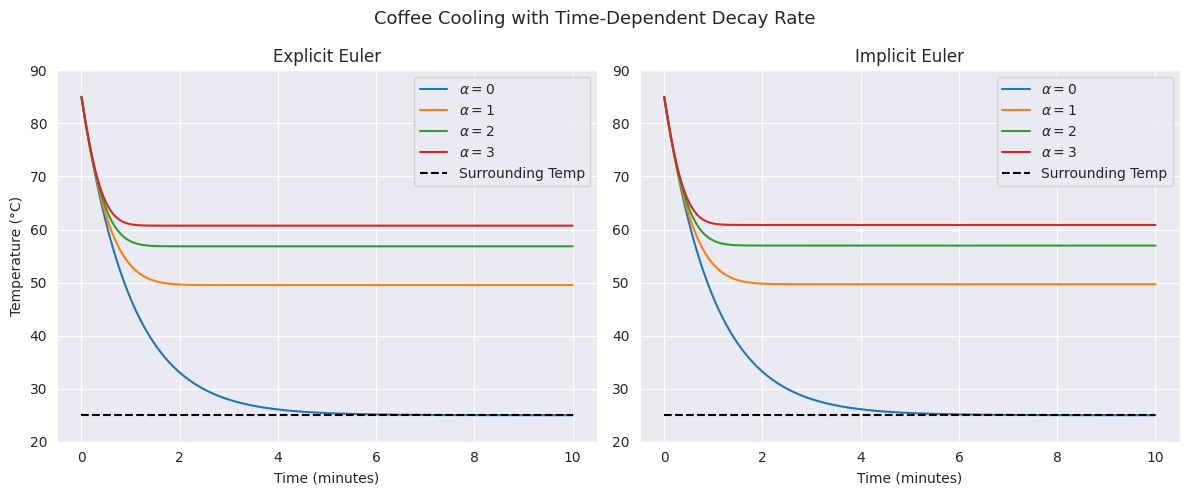

In [2]:
def euler_explicit(Ts=25, T0=85, alpha=0, h=0.01, t_final=10):
    t = np.arange(0, t_final + h, h)
    r = np.exp(-alpha * (t ** 2))
    T = [T0]
    Ti = T0
    for i in range(1, len(t)):
        Ti = Ti - h * (Ti - Ts) * r[i - 1]
        T.append(Ti)
    return t, np.array(T)

def euler_implicit(Ts=25, T0=85, alpha=0, h=0.01, t_final=10):
    t = np.arange(0, t_final + h, h)
    r = np.exp(-alpha * (t ** 2))
    T = [T0]
    Ti = T0
    for i in range(1, len(t)):
        Ti = (Ti + h * Ts * r[i - 1]) / (1 + h * r[i - 1])
        T.append(Ti)
    return t, np.array(T)

alphas = [0, 1, 2, 3]
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for alpha in alphas:
    t, T = euler_explicit(alpha=alpha)
    axs[0].plot(t, T, label=fr'$\alpha = {alpha}$')
axs[0].plot(t, np.full_like(t, 25), 'k--', label='Surrounding Temp')
axs[0].set_title('Explicit Euler')
axs[0].set_xlabel('Time (minutes)')
axs[0].set_ylabel('Temperature (°C)')
axs[0].set_ylim(20, 90)
axs[0].grid(True)
axs[0].legend()

for alpha in alphas:
    t, T = euler_implicit(alpha=alpha)
    axs[1].plot(t, T, label=fr'$\alpha = {alpha}$')
axs[1].plot(t, np.full_like(t, 25), 'k--', label='Surrounding Temp')
axs[1].set_title('Implicit Euler')
axs[1].set_xlabel('Time (minutes)')
axs[1].set_ylim(20, 90)
axs[1].grid(True)
axs[1].legend()

plt.suptitle('Coffee Cooling with Time-Dependent Decay Rate', fontsize=13)
plt.tight_layout()
plt.show()

2. Find the most accurate formula for the first derivative of the function $f$ at $x_i$ utilising known values of $f$ at $x_{i-1},x_i,x_{i+1}$ and $x_{i+2}$. The points are uniformly spaced. Give the leading error term and state the order of the method.

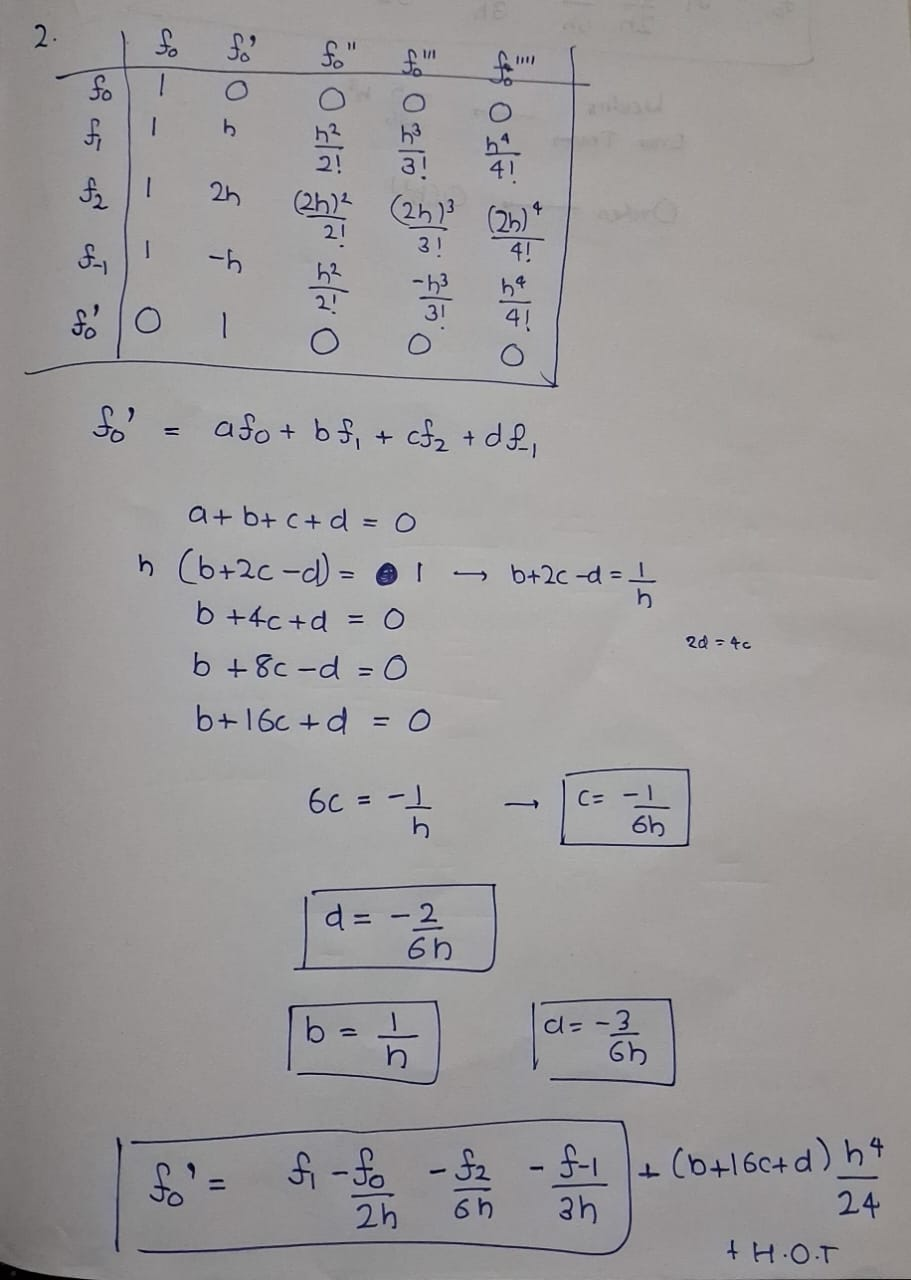

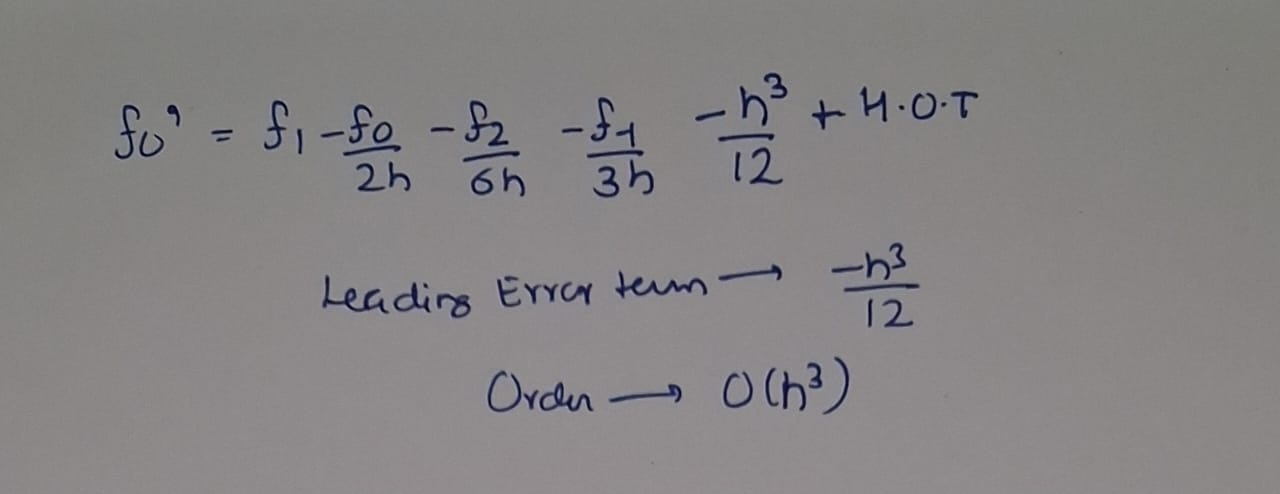

3. A general Pad\'e type boundary scheme (at $i=0$) for the first derivative which doesn't alter the tridiagonal structure of the matrix can be written as
    $$f_0'+\alpha f_1' = \dfrac1h \left(af_0+bf_1+cf_2+df_3\right)$$
    * Obtain $a,b,c,d$ in terms of $\alpha$ so that the scheme is at least third-order accurate.
	* Which $\alpha$ would you choose and why?
	* Find all the coefficients so that the scheme would be fourth-order accurate.

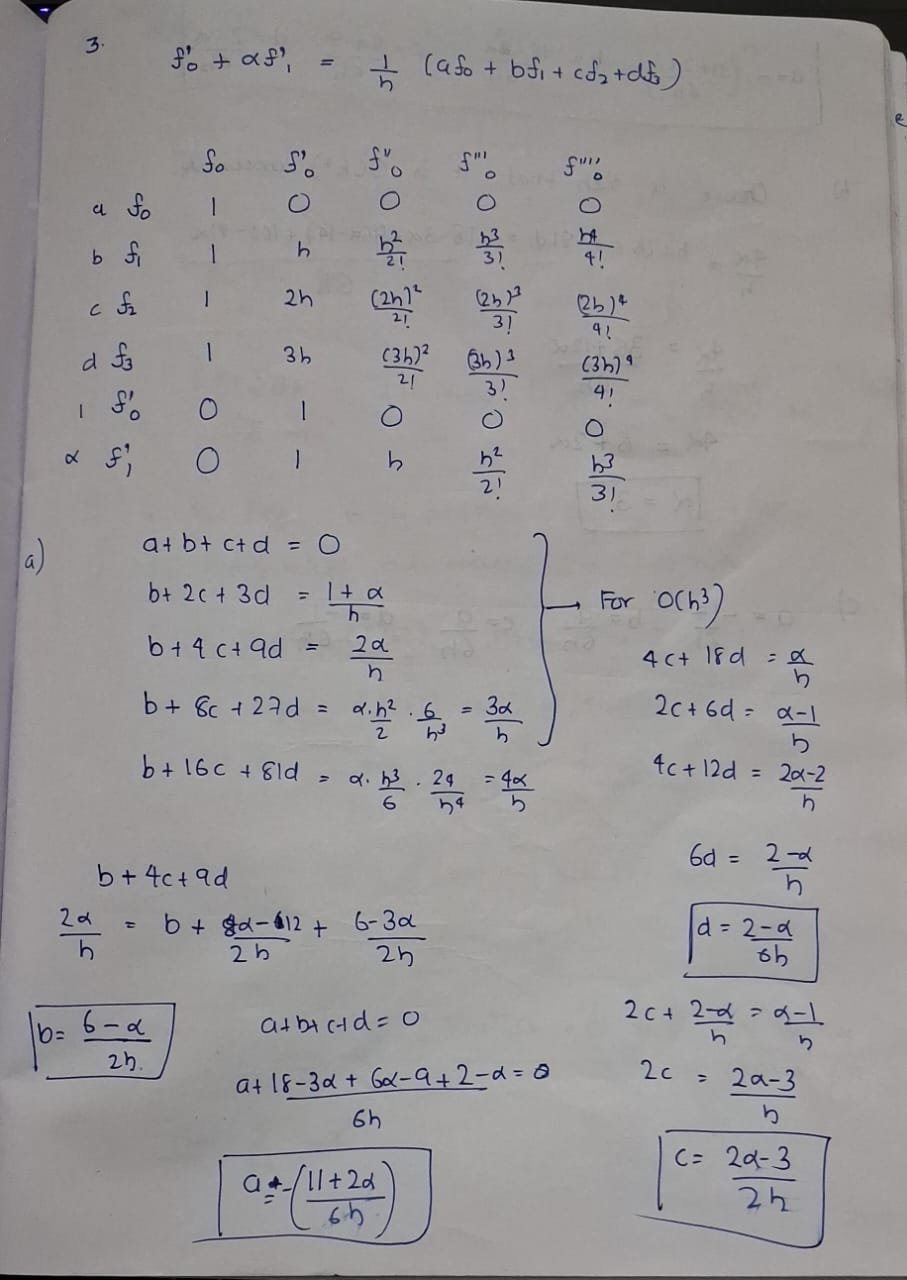

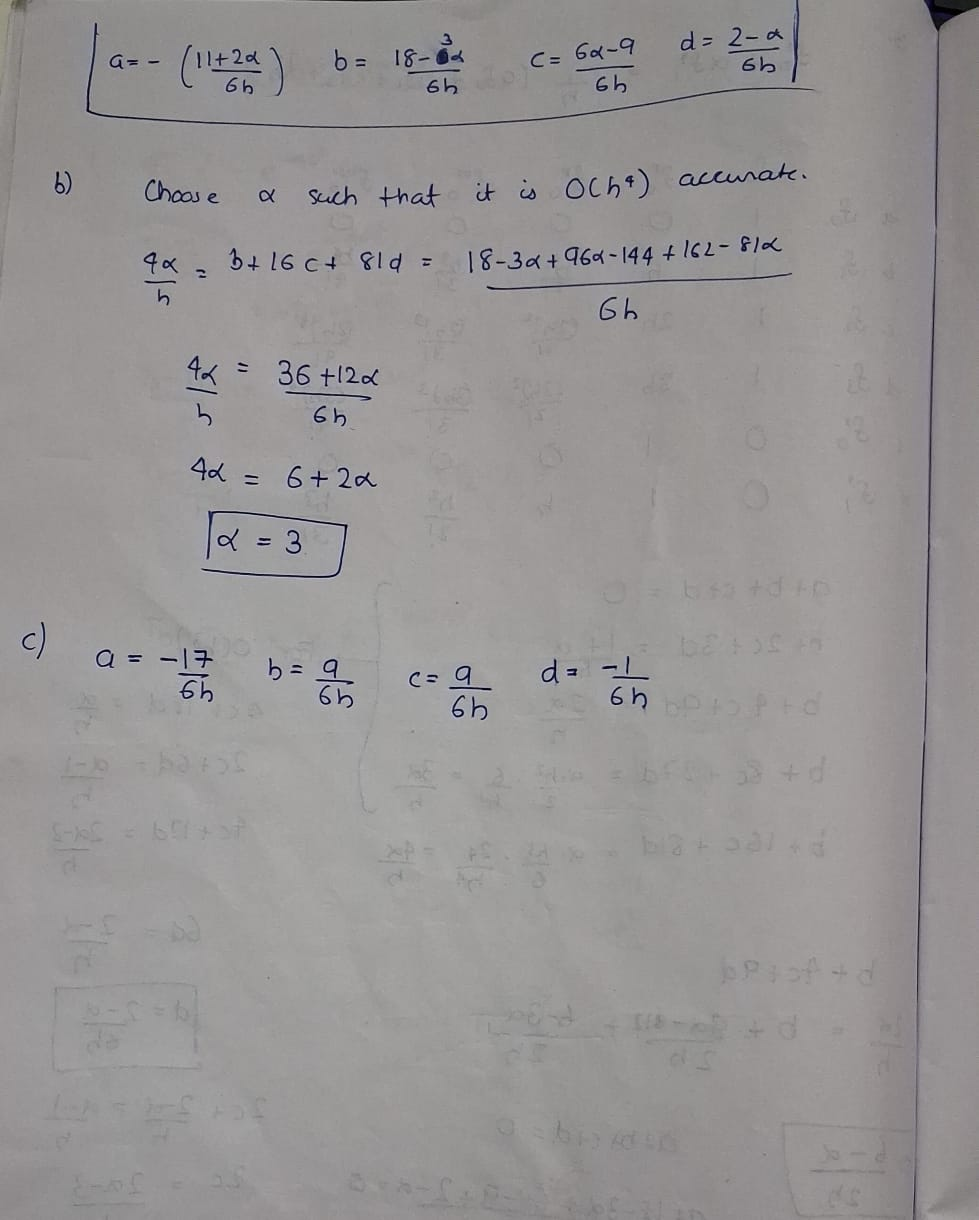

4. In numerical solution of boundary value problems in differential equations, we can sometimes use the physics of the problem not only to enforce the boundary conditions but also to maintain high-order accuracy near the boundary. Suppose we want to numerically solve the following boundary value problem $\displaystyle\frac{d^2y}{dx^2}+y = x^3$ where $0\leq x \leq 1$ with Neumann boundary conditions $y'(0) = y'(1) = 0$.
* Discretize the domain using grid points $x_i = (i-0.5)h$, $i \in \{1,2,\ldots,N\}$. Note that there are no grid points on the boundaries. In this problem, $y_i$ is the numerical estimate of $y$ at $x_i$.
* By using a finite difference scheme, we can estimate $y_i''$ in terms of linear combinations of $y_i$'s and transform the ODE into a linear system of equations. Use the Pad\'e formula for the interior points.
* For the left boundary, derive a third order Pad\'e scheme to approximate $y_0''$ in the following form: $y_1''+b_2y_2'' = a_1y_1 + a_2y_2 + a_3y_3 + a_4y_b' + \mathcal{O}\left(h^3 \right)$ where $y_b' = y'(0)$, which is known from the boundary condition at $x=0$.
* Repeat the previous step for the right boundary.
* Using the finite difference formulae derived above, we can write the following linear relation: $A \begin{bmatrix}
			y_1''\\
			y_2''\\
			\vdots\\
			y_N''
			\end{bmatrix}
			=B \begin{bmatrix}
			y_1\\
			y_2\\
			\vdots\\
			y_N
			\end{bmatrix}$
* What are the elements of the matrices $A$ and $B$ operating on the interior and boundary nodes?
* Use this relationship to transform the ODE into a system with $y_i$'s as unknowns. Use $N=24$ and solve this system. Do you actually have to invert $A$?
* Plot the exact and numerical solutions. Discuss your result. How are the Neumann boundary conditions enforced into the discretized boundary value problem?

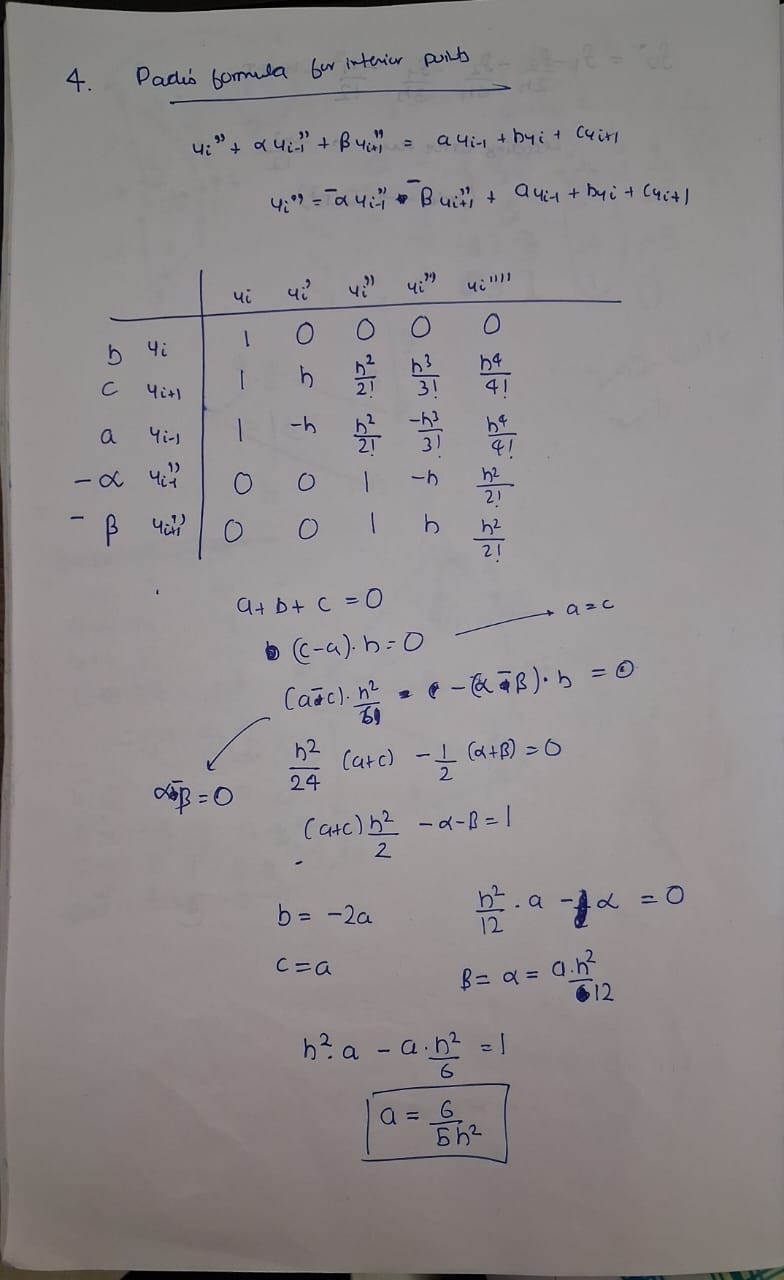

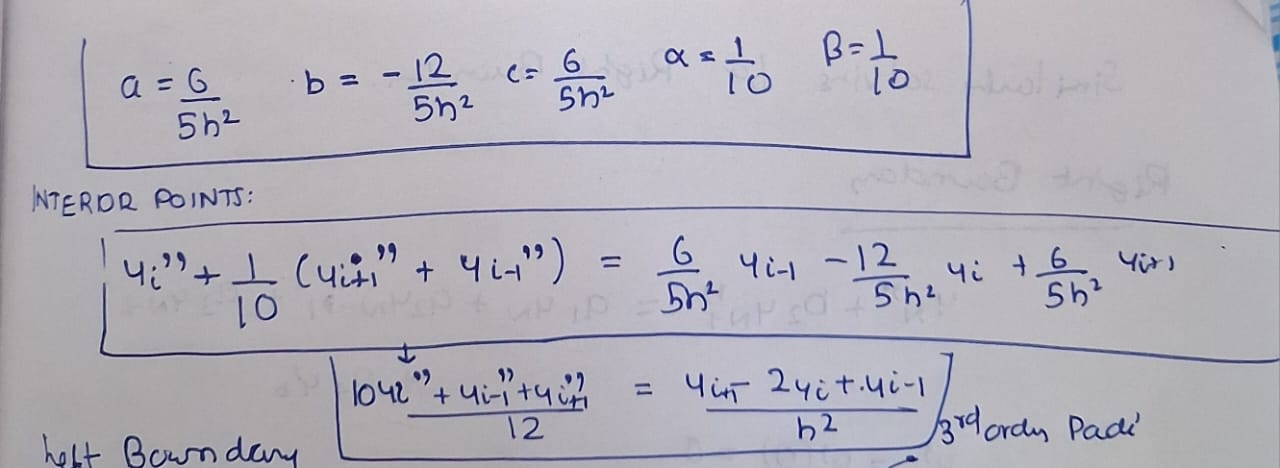

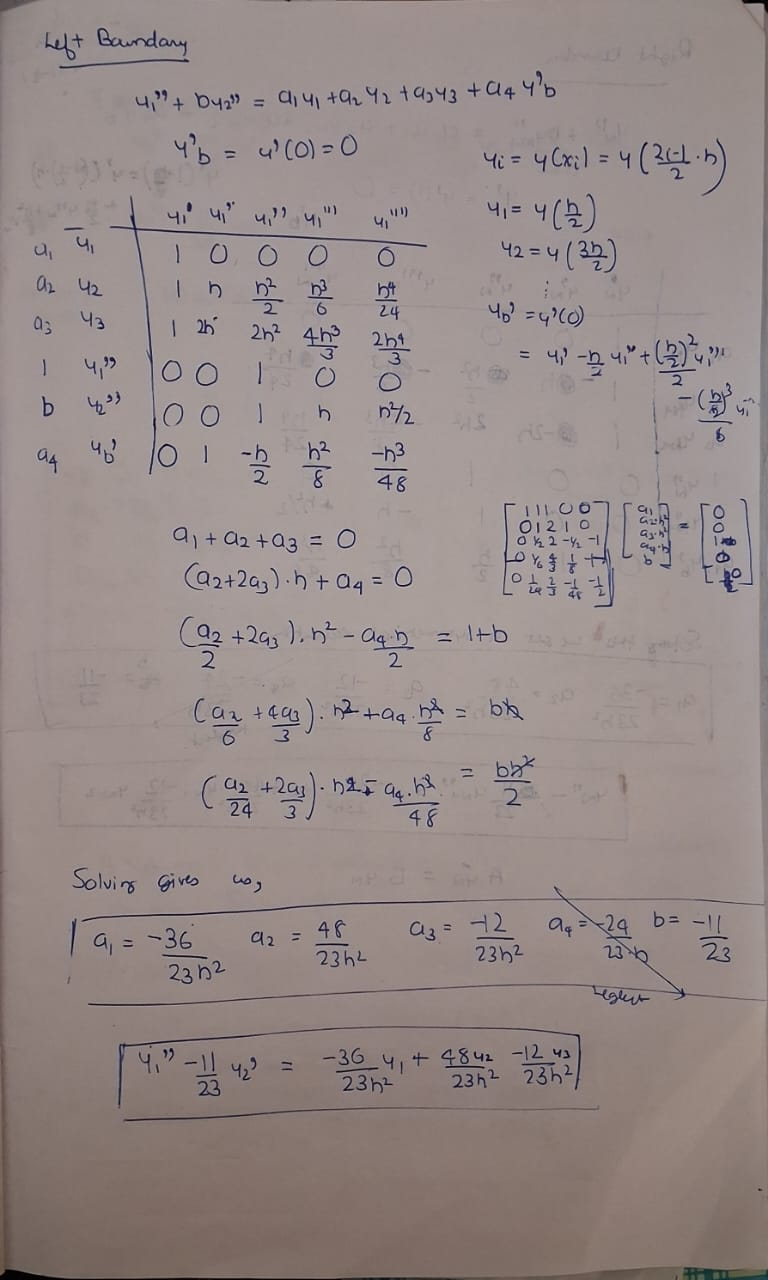

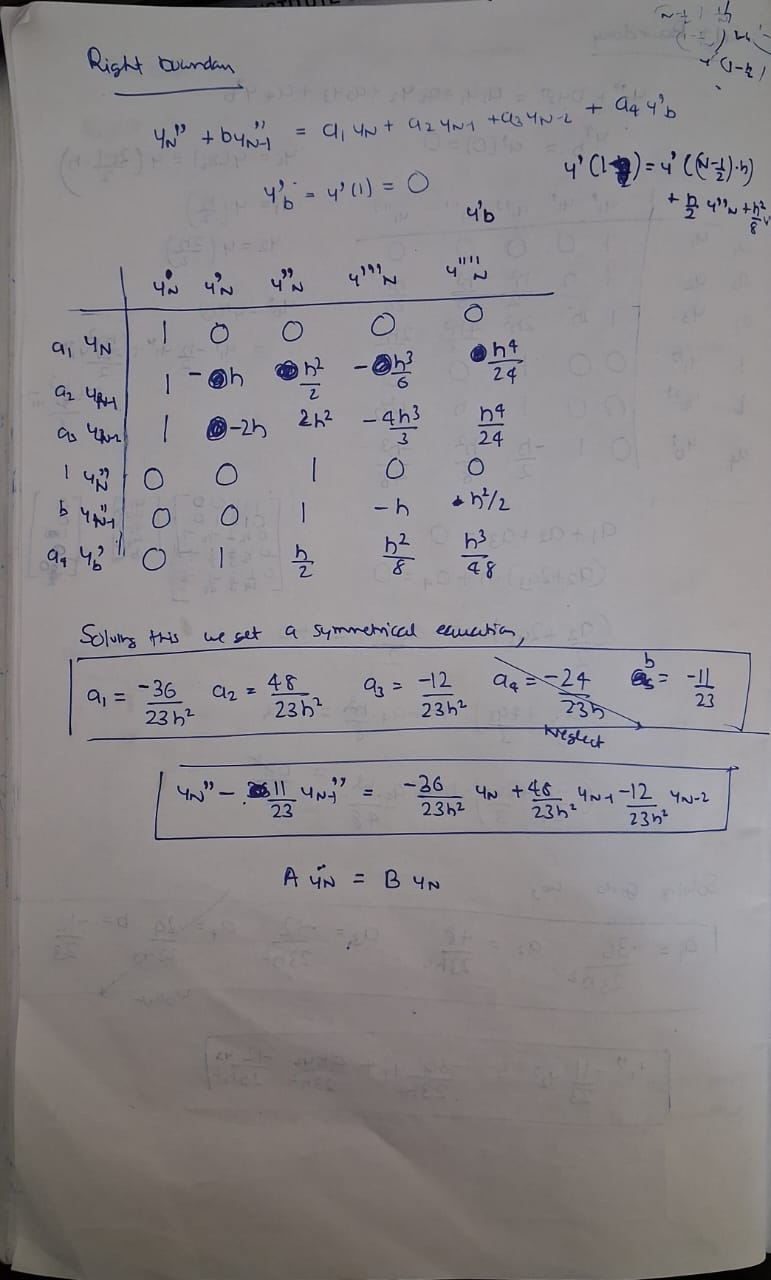

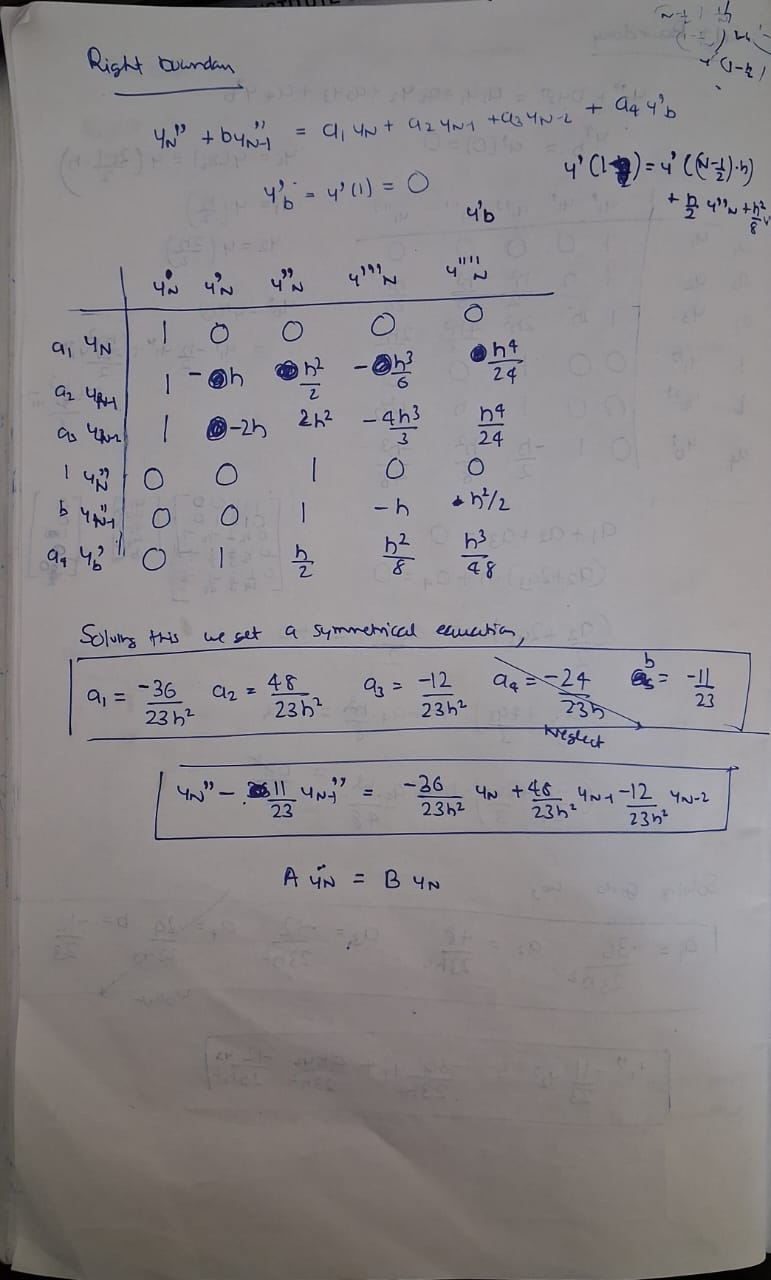

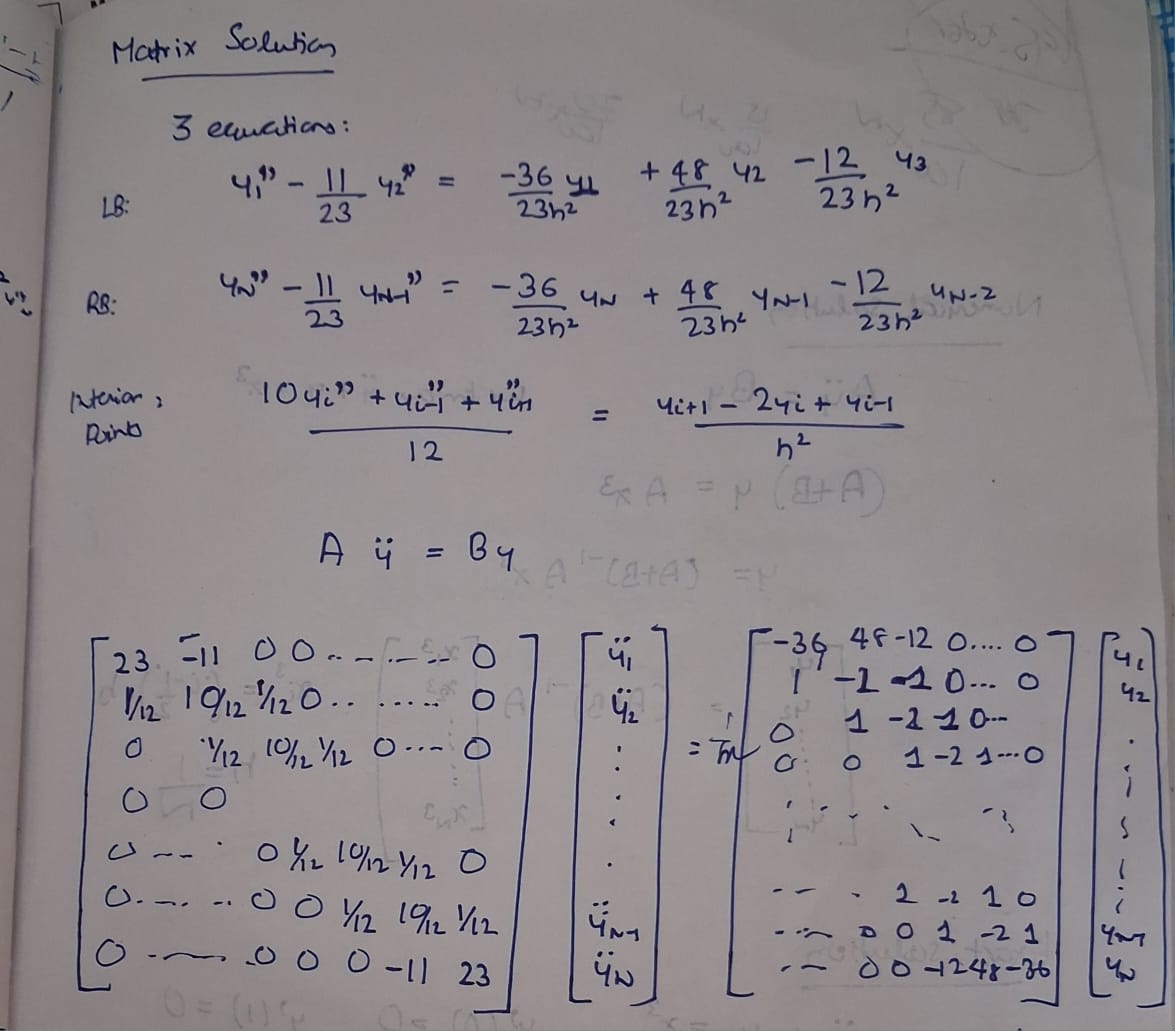

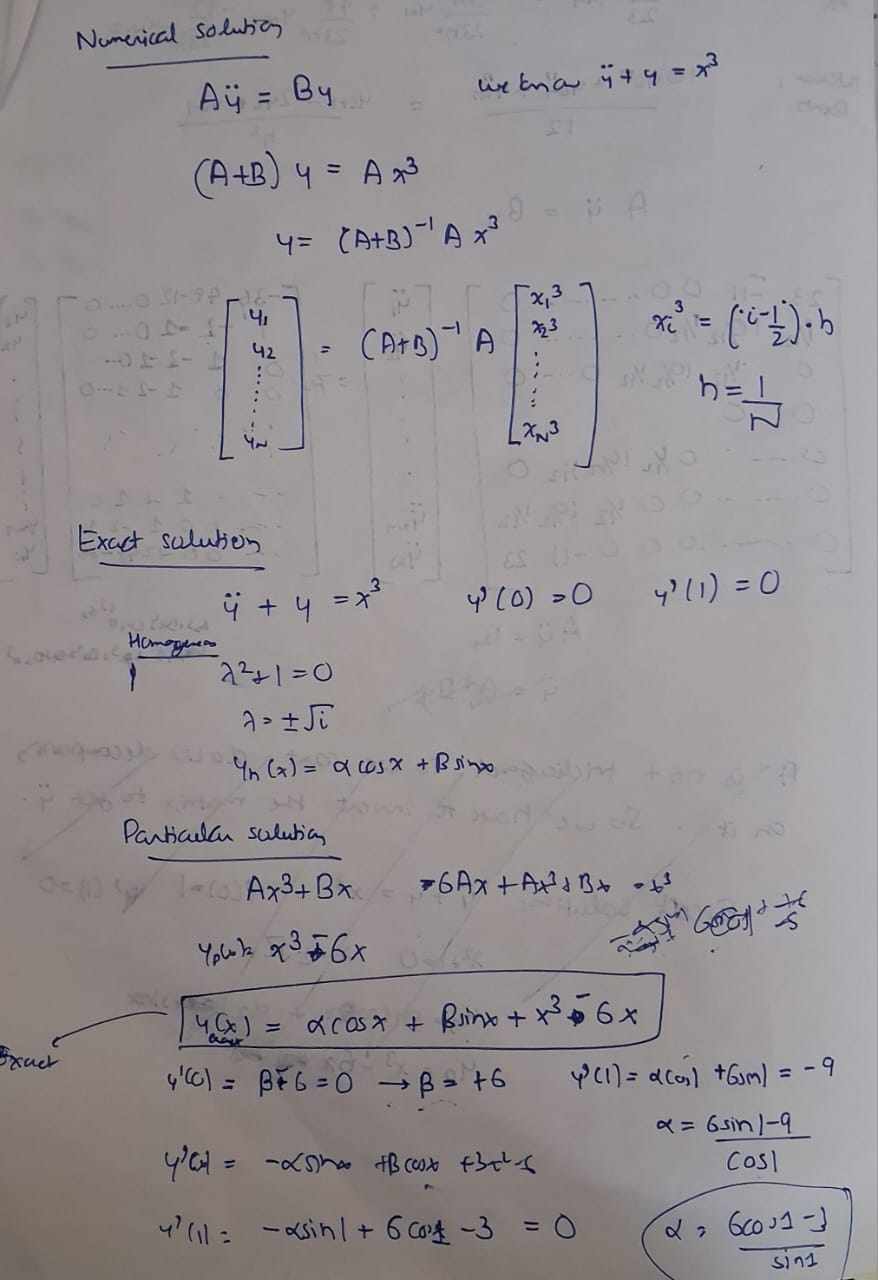

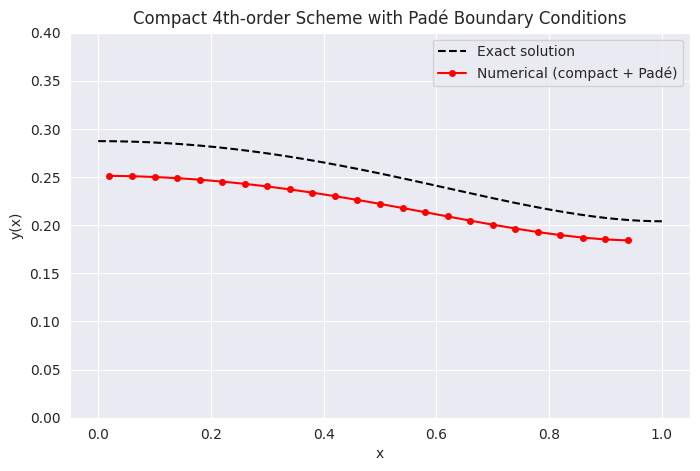

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('dark')

N = 24
A = np.zeros((N, N))
B = np.zeros((N, N))
x = np.zeros(N)
x3 = np.zeros(N)
h = 1 / (N + 1)

for i in range(N):
    x[i] = (i + 0.5) * h
    x3[i] = x[i]**3


A[0, 0] = 23
A[0, 1] = -11

A[N-1, N-1] = 23
A[N-1, N-2] = -11

for i in range(1, N-1):
    A[i, i-1] = 1/12
    A[i, i]   = 10/12
    A[i, i+1] = 1/12

# Left boundary row
B[0, 0] = -36/(h**2)
B[0, 1] = 48/(h**2)
B[0, 2] = -12/(h**2)

# Right boundary row
B[N-1, N-1] = -36/(h**2)
B[N-1, N-2] = 48/(h**2)
B[N-1, N-3] = -12/(h**2)

# Interior (correcting your typo B[i-1,i+1])
for i in range(1, N-1):
    B[i, i-1] = 1/(h**2)
    B[i, i]   = -2/(h**2)
    B[i, i+1] = 1/(h**2)

# ------------------------------------------------------------
# Solve system:   (A+B) y = A x^3
# ------------------------------------------------------------
M = A + B
rhs = A @ x3

y_num = np.linalg.solve(M, rhs)

def exact_solution(x):
    yp = x**3 - 6*x
    C2 = 6
    C1 = (C2*np.cos(1) - 3) / np.sin(1)

    return C1*np.cos(x) + C2*np.sin(x) + yp

x_plot = np.linspace(0, 1, 200)
y_exact = exact_solution(x_plot)

plt.figure(figsize=(8,5))
plt.plot(x_plot, y_exact, 'k--', label="Exact solution")
plt.plot(x, y_num, 'ro-', label="Numerical (compact + Padé)", markersize=4)
plt.grid(True)
plt.legend()
plt.xlabel("x")
plt.ylabel("y(x)")
plt.ylim(0,0.4)
plt.title("Compact 4th-order Scheme with Padé Boundary Conditions")
plt.show()


- The Neumann boundary conditions are enforced in the BVP by first including a4 when calculating the value of the boundary values and then neglecting the a4 term or cancelling it out as y'(0)=y'(1)=0 in the Pade Boundary Conditions.
- Yes we need to invert it, since the matrix is not tridiagonal. So we cant perform LU decomposition on it.